<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [245]:
#Importation des librairies
import pandas as pd

import seaborn as sns

import scipy.stats as sc


import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

import squarify

pd.set_option('display.float_format', '{:.2f}'.format)

In [246]:
#Importation de la librairie plotly express
import plotly.express as px

In [247]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

Attention ! Pensez à bien modifier le chemin :

In [250]:
import os

# Modifiez le chemin vers votre dossier contenant le notebook et les fichiers csv.
os.chdir(r"C:\Users\victo\OneDrive\Dokumente\Projet OC\OCP6")

# Pour vérifier
print("Nouveau répertoire :", os.getcwd())

Nouveau répertoire : C:\Users\victo\OneDrive\Dokumente\Projet OC\OCP6


In [251]:
try:
    erp = pd.read_csv('erp.csv')
    web = pd.read_csv('web.csv')
    liaison = pd.read_csv('liaison.csv')
    print("✅ Les fichiers ont bien été chargés.")
except Exception as e:
    print("❌ Erreur lors du chargement :", e)

✅ Les fichiers ont bien été chargés.


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [254]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [255]:
#Consulter le nombre de colonnes
erp.columns

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price'],
      dtype='object')

In [256]:
#La nature des données dans chacune des colonnes
erp.dtypes

product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object

In [257]:
#Le nombre de valeurs présentes dans chacune des colonnes
erp.count(axis=0, numeric_only=False)

product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64

In [258]:
#Afficher les 5 premières lignes de la table
erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.20,16,instock,12.88
1,3849,1,34.30,10,instock,17.54
2,3850,1,20.80,0,outofstock,10.64
3,4032,1,14.10,26,instock,6.92
4,4039,1,46.00,3,outofstock,23.77


In [259]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
list_product_id = []

for product_id in erp['product_id']:
   if product_id is not None:
     list_product_id.append(product_id)
     nb_id = list_product_id.count(product_id)
     if nb_id > 1:
        print("au moins un identifiant n'est pas unique")
        break
else:
    print("les product_id sont uniques et non nuls")

les product_id sont uniques et non nuls


In [260]:
#Afficher les valeurs distinctes de la colonne stock_status
print(erp['stock_status'].unique())



['instock' 'outofstock']


In [261]:
#À quelle(s) autre(s) colonne(s) sont-elles liées ?

Logiquement, stock_status devrait être relié à stock_quantity. Mais aussi éventuelemnt à onsale_web.

In [263]:
#On commence par renommer la colonne et la transformer en booléen
erp_nettoye = erp.rename(columns={'stock_status': 'in_stock'})

erp_nettoye['in_stock'] = erp_nettoye['in_stock'].map({"instock": True, "outofstock": False})
print(erp_nettoye['in_stock'].unique())

[ True False]


Ok, maintenant, on va tester les liens logiques entre les variables booléennes et les autres variables :

1 : si in_stock est True alors stock_quantity > 0

2 : si onsale_web est True alors in stock true et stock quantity > 0

In [265]:
for i, row in erp_nettoye.iterrows():
    if row['in_stock'] == True and row['stock_quantity'] < 1:
        print(f"Incohérence dans le fichier à la ligne {i}")
        break
else:
    print("Le fichier est cohérent dans la relation entre stock_quantity et in_stock")

Incohérence dans le fichier à la ligne 398


On a trouvé une incohérence. Maintenant on va vérifier pour toutes les lignes :

In [267]:
for i, row in erp_nettoye.iterrows():
    if row['in_stock'] == True and row['stock_quantity'] < 1:
        print(f"Ligne incohérente index={i}: {row.to_dict()}")

Ligne incohérente index=398: {'product_id': 4885, 'onsale_web': 1, 'price': 18.7, 'stock_quantity': 0, 'in_stock': True, 'purchase_price': 9.66}


Une seule ligne incohérente, on va changer la valeur du booléen pour conserver la relation logique

In [269]:
for i, row in erp_nettoye.iterrows():
    if row['in_stock'] == True and row['stock_quantity'] < 1:
        erp_nettoye.loc[i, 'in_stock'] = False

Et vice-versa :

In [271]:
for i, row in erp_nettoye.iterrows():
    if row['in_stock'] == False and row['stock_quantity'] > 0:
        erp_nettoye.loc[i, 'in_stock'] = True

Vérification :

In [273]:
for i, row in erp_nettoye.iterrows():
    if row['in_stock'] == True and row['stock_quantity'] < 1:
        print(f"Incohérence dans le fichier à la ligne {i}")
        break
    elif row['in_stock'] == False and row['stock_quantity'] > 0:
        print(f"Incohérence dans le fichier à la ligne {i}")
        break
else:
    print("Le fichier est cohérent dans la relation entre stock_quantity et in_stock")

Le fichier est cohérent dans la relation entre stock_quantity et in_stock


In [274]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"


In [275]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
# df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

In [276]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset

In [277]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [278]:
#Corriger la ou les données incohérentes

#Vérification en utilisant le même code que plus haut pour afficher les problèmes


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [281]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
# print("Nombres d'articles avec un prix non renseigné: {}".format()) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"

#Afficher le prix maximum de la colonne "price"

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)


On va commencer par vérifier s'il y a des valeurs nulles :

In [283]:
for i, row in erp_nettoye.iterrows():
    if row['price'] == None :
        print(f"Valeur nulle trouvée à la ligne {i}")
        break
else:
    print("Tout produit a un prix")

Tout produit a un prix


On va faire le reste en une seule instruction :

<Axes: xlabel='price', ylabel='Count'>

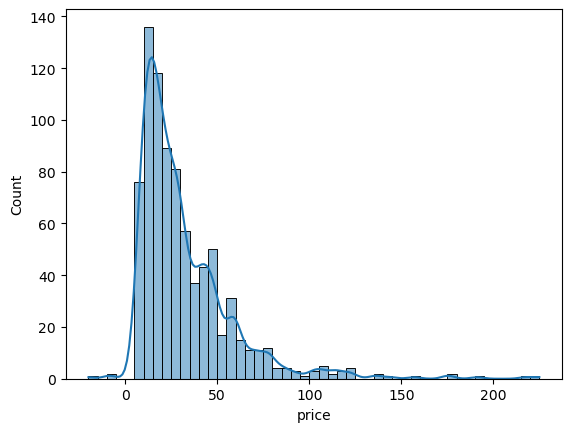

In [285]:
sns.histplot(erp_nettoye, x='price', binwidth=5, kde=True, kde_kws={'bw_adjust': 0.5})

Courbe assymétrique dégressive, logique pour une distribution de prix (beaucoup de produits bons marchés, quelques produits très chers).

Par contre, valeurs négatives = impossible. On supposera une faute de frappe. On va les refaire passer en positif.

Pas de valeurs aberrantes évidentes. Des bouteilles de vin entre 150 et 250 ça existe. 

In [287]:

erp_nettoye['price'] = erp_nettoye['price'].abs()

for price in erp_nettoye['price']:
   if price < 0:
       print("Le nettoyage n'a pas fonctionné")
       break
else:
    print("Le nettoyage a fonctionné")

Le nettoyage a fonctionné


<Axes: xlabel='price', ylabel='Count'>

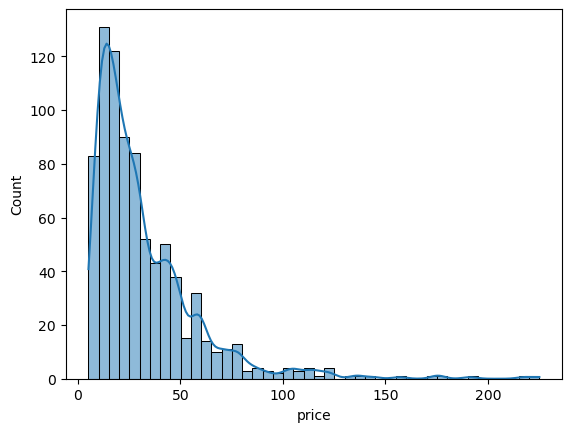

In [288]:
sns.histplot(erp_nettoye, x='price', binwidth=5, kde=True, kde_kws={'bw_adjust': 0.5})

Prix : OK.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [291]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"

#Afficher la quantité maximum de la colonne "stock_quantity"

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)


On va commencer par vérifier s'il y a des valeurs nulles :

In [293]:
for i, row in erp_nettoye.iterrows():
    if row['stock_quantity'] == None :
        print(f"Valeur nulle trouvée à la ligne {i}")
        break
else:
    print("Tout produit a un stock")

Tout produit a un stock


<Axes: xlabel='stock_quantity', ylabel='Count'>

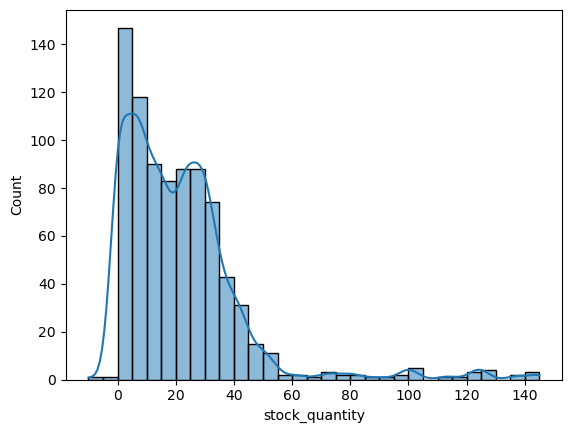

In [294]:
sns.histplot(erp_nettoye, x='stock_quantity', binwidth=5, kde=True, kde_kws={'bw_adjust': 0.5})

Bon, on a des stock_quantity < 0 ce qui est évidement impossible. On va utiliser clip pour définir 0 comme le minimum. Cela nous permet de rester cohérent avec stock_status. 

In [296]:
erp_nettoye['stock_quantity'] = erp_nettoye['stock_quantity'].clip(lower=0)

<Axes: xlabel='stock_quantity', ylabel='Count'>

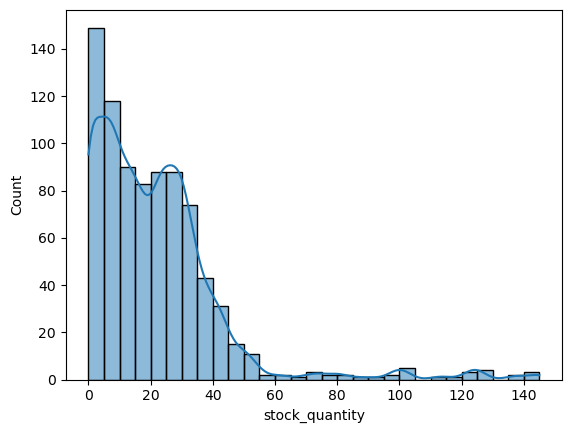

In [297]:
sns.histplot(erp_nettoye, x='stock_quantity', binwidth=5, kde=True, kde_kws={'bw_adjust': 0.5})

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [299]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
print(erp_nettoye['onsale_web'].unique())

[1 0]


1 = True ; 0 = False.

In [301]:
erp_nettoye['onsale_web'] = erp_nettoye['onsale_web'].map({0: False, 1: True})
print(erp_nettoye['onsale_web'].unique())

[ True False]


Pour le plaisir, on testera la relation entre stock_quantity et onsale_web, logiquement si c'est en vente sur le web, on devrait avoir des éléments en stock :


In [303]:
for i, row in erp_nettoye.iterrows():
    if (row['onsale_web'] == True and row['stock_quantity'] < 1) or (row['in_stock'] == False):
        print("Incohérence dans le fichier à la ligne", i)
        break
else:
    print("Le fichier est cohérent dans la relation entre onsale_web, stock_quantity et in_stock")

Incohérence dans le fichier à la ligne 2


On va vérifier pour toutes les lignes : 

In [305]:
for i, row in erp_nettoye.iterrows():
    if row['onsale_web'] == True and (row['stock_quantity'] < 1 or (row['in_stock'] == False)):
        print(f"Ligne incohérente index={i}: {row.to_dict()}")

Ligne incohérente index=2: {'product_id': 3850, 'onsale_web': True, 'price': 20.8, 'stock_quantity': 0, 'in_stock': False, 'purchase_price': 10.64}
Ligne incohérente index=8: {'product_id': 4043, 'onsale_web': True, 'price': 60.0, 'stock_quantity': 0, 'in_stock': False, 'purchase_price': 29.45}
Ligne incohérente index=11: {'product_id': 4047, 'onsale_web': True, 'price': 18.3, 'stock_quantity': 0, 'in_stock': False, 'purchase_price': 9.93}
Ligne incohérente index=15: {'product_id': 4051, 'onsale_web': True, 'price': 7.7, 'stock_quantity': 0, 'in_stock': False, 'purchase_price': 4.14}
Ligne incohérente index=16: {'product_id': 4052, 'onsale_web': True, 'price': 33.7, 'stock_quantity': 0, 'in_stock': False, 'purchase_price': 18.11}
Ligne incohérente index=28: {'product_id': 4065, 'onsale_web': True, 'price': 19.5, 'stock_quantity': 0, 'in_stock': False, 'purchase_price': 9.67}
Ligne incohérente index=42: {'product_id': 4079, 'onsale_web': True, 'price': 37.0, 'stock_quantity': 0, 'in_sto

Trop d'incohérences, on_sale_web peut être True alors que le stock est à 0 ? Dans un contexte pro, il faudrait en discuter avec la boutique. 

Dans le cadre de cet exercice, on va considérer que les variables ne sont finalement pas corrélées. 

In [307]:
#Quelles sont les colonnes à conserver selon vous?
erp_nettoye.columns

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'in_stock',
       'purchase_price'],
      dtype='object')

Toutes !

In [309]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [311]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
#Afficher le prix minimum de la colonne "purchase_price"

#Afficher le prix maximum de la colonne "purchase_price"


On va commencer par vérifier s'il y a des valeurs nulles :

In [313]:
for i, row in erp_nettoye.iterrows():
    if row['stock_quantity'] == None :
        print(f"Valeur nulle trouvée à la ligne {i}")
        break
else:
    print("Tout produit a un prix d'achat")

Tout produit a un prix d'achat


<Axes: xlabel='purchase_price', ylabel='Count'>

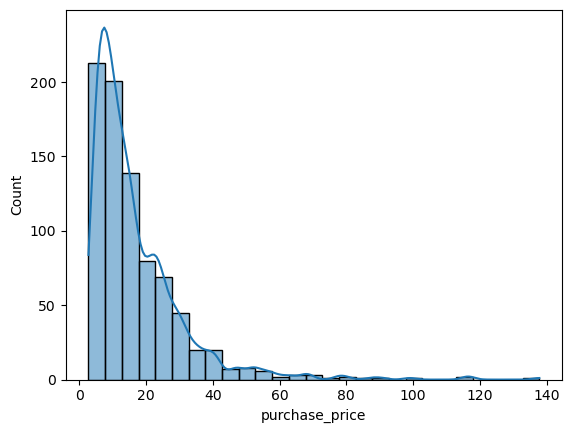

In [314]:
sns.histplot(erp_nettoye, x='purchase_price', binwidth=5, kde=True, kde_kws={'bw_adjust': 0.5})

Ok, in fine ça semble logique. Pas de purchase_price null, pas de valeurs négatives et maximum inférieur au prix d'achat.

Pour le plaisir du jeu, on va tester la corrélation entre prix de vente et d'achat pour voir la robustesse du dataframe.

In [317]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(erp_nettoye['price'], erp_nettoye['purchase_price'])
print("Corrélation Pearson :", corr)
print("p-value :", p_value)

if p_value < 0.5:
   print("Corrélation significative")
else :
    print("Corrélation non significative")

Corrélation Pearson : 0.9693704304344265
p-value : 0.0
Corrélation significative


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [319]:
#Dimension du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(web.shape[1]))

Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [320]:
#Nombre d'observations
web.count(axis=0, numeric_only=False)

sku                      1428
virtual                  1513
downloadable             1513
rating_count             1513
average_rating           1430
total_sales              1430
tax_status                716
tax_class                   0
post_author              1430
post_date                1430
post_date_gmt            1430
post_content                0
product_type             1429
post_title               1430
post_excerpt              716
post_status              1430
comment_status           1430
ping_status              1430
post_password               0
post_name                1430
post_modified            1430
post_modified_gmt        1430
post_content_filtered       0
post_parent              1430
guid                     1430
menu_order               1430
post_type                1430
post_mime_type            714
comment_count            1430
dtype: int64

In [321]:
#Consulter le nombre de colonnes
web.columns

Index(['sku', 'virtual', 'downloadable', 'rating_count', 'average_rating',
       'total_sales', 'tax_status', 'tax_class', 'post_author', 'post_date',
       'post_date_gmt', 'post_content', 'product_type', 'post_title',
       'post_excerpt', 'post_status', 'comment_status', 'ping_status',
       'post_password', 'post_name', 'post_modified', 'post_modified_gmt',
       'post_content_filtered', 'post_parent', 'guid', 'menu_order',
       'post_type', 'post_mime_type', 'comment_count'],
      dtype='object')

In [322]:
#La nature des données dans chacune des colonnes
web.dtypes

sku                       object
virtual                    int64
downloadable               int64
rating_count               int64
average_rating           float64
total_sales              float64
tax_status                object
tax_class                float64
post_author              float64
post_date                 object
post_date_gmt             object
post_content             float64
product_type              object
post_title                object
post_excerpt              object
post_status               object
comment_status            object
ping_status               object
post_password            float64
post_name                 object
post_modified             object
post_modified_gmt         object
post_content_filtered    float64
post_parent              float64
guid                      object
menu_order               float64
post_type                 object
post_mime_type            object
comment_count            float64
dtype: object

In [323]:
#Selon vous, quelles sont les colonnes à conserver ?
for col in web.columns:
       if web[col].nunique() <= 1:
         print(col, web[col].unique())
    

virtual [0]
downloadable [0]
rating_count [0]
average_rating [ 0. nan]
tax_status [nan 'taxable']
tax_class [nan]
post_content [nan]
post_status ['publish' nan]
comment_status ['closed' nan]
ping_status ['closed' nan]
post_password [nan]
post_content_filtered [nan]
post_parent [ 0. nan]
menu_order [ 0. nan]
post_mime_type ['image/jpeg' nan]
comment_count [ 0. nan]


Donc là, on voit qu'il y a beaucoup de colonnes avec une seule et unique valeur. Et certaines colonnes avec une valeur et un nan. Pour ces dernières, on va supposer que c'est des booléens (si rempli, True, sinon False) et qu'elles contiennent des informations exploitables. 

Pour les autres, clairement l'information est nulle. On va les supprimer. 

In [325]:
#Selon vous, quelles sont les colonnes à conserver ?
for col in web.columns.tolist():
    uniques = web[col].unique()  
    if len(uniques) == 1:              
        print("Colonne supprimée :", col, "→ valeur :", uniques)
        web.drop(columns=[col], inplace=True)

Colonne supprimée : virtual → valeur : [0]
Colonne supprimée : downloadable → valeur : [0]
Colonne supprimée : rating_count → valeur : [0]
Colonne supprimée : tax_class → valeur : [nan]
Colonne supprimée : post_content → valeur : [nan]
Colonne supprimée : post_password → valeur : [nan]
Colonne supprimée : post_content_filtered → valeur : [nan]


In [326]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération


C'est fait !

In [328]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
for i, row in web.iterrows():
    if pd.isna(row['sku']):
        print(f"Ligne sans sku index={i}: {row.to_dict()}")

Ligne sans sku index=8: {'sku': nan, 'average_rating': nan, 'total_sales': nan, 'tax_status': nan, 'post_author': nan, 'post_date': nan, 'post_date_gmt': nan, 'product_type': nan, 'post_title': nan, 'post_excerpt': nan, 'post_status': nan, 'comment_status': nan, 'ping_status': nan, 'post_name': nan, 'post_modified': nan, 'post_modified_gmt': nan, 'post_parent': nan, 'guid': nan, 'menu_order': nan, 'post_type': nan, 'post_mime_type': nan, 'comment_count': nan}
Ligne sans sku index=20: {'sku': nan, 'average_rating': nan, 'total_sales': nan, 'tax_status': nan, 'post_author': nan, 'post_date': nan, 'post_date_gmt': nan, 'product_type': nan, 'post_title': nan, 'post_excerpt': nan, 'post_status': nan, 'comment_status': nan, 'ping_status': nan, 'post_name': nan, 'post_modified': nan, 'post_modified_gmt': nan, 'post_parent': nan, 'guid': nan, 'menu_order': nan, 'post_type': nan, 'post_mime_type': nan, 'comment_count': nan}
Ligne sans sku index=30: {'sku': nan, 'average_rating': nan, 'total_sal

Là, on voit que les skus vides correspondent principalement à des lignes, plutôt vides....

In [330]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les :
for i, row in web.iterrows():
    try:
        int(row['sku'])
    except (ValueError, TypeError):
        print(f"Ligne sku non entier index={i}: {row.to_dict()}")

Ligne sku non entier index=8: {'sku': nan, 'average_rating': nan, 'total_sales': nan, 'tax_status': nan, 'post_author': nan, 'post_date': nan, 'post_date_gmt': nan, 'product_type': nan, 'post_title': nan, 'post_excerpt': nan, 'post_status': nan, 'comment_status': nan, 'ping_status': nan, 'post_name': nan, 'post_modified': nan, 'post_modified_gmt': nan, 'post_parent': nan, 'guid': nan, 'menu_order': nan, 'post_type': nan, 'post_mime_type': nan, 'comment_count': nan}
Ligne sku non entier index=20: {'sku': nan, 'average_rating': nan, 'total_sales': nan, 'tax_status': nan, 'post_author': nan, 'post_date': nan, 'post_date_gmt': nan, 'product_type': nan, 'post_title': nan, 'post_excerpt': nan, 'post_status': nan, 'comment_status': nan, 'ping_status': nan, 'post_name': nan, 'post_modified': nan, 'post_modified_gmt': nan, 'post_parent': nan, 'guid': nan, 'menu_order': nan, 'post_type': nan, 'post_mime_type': nan, 'comment_count': nan}
Ligne sku non entier index=30: {'sku': nan, 'average_rating

Ils sont deux ! Ce n'est pas la peine des les supprimer, si on merge les fichiers avec un inner join, de toutes manières, ça ne conservera que les correspondances.

In [332]:
#Identifier les lignes sans code article


In [333]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre

On va supprimer les lignes où tout est vide :

In [335]:
web_nettoye = web.copy()

rows_to_delete = []

for i, row in web_nettoye.iterrows():
    empty = True
    for col in web.columns:
        if col != 'sku':  # on ignore sku, déjà NaN
            if not (pd.isna(row[col]) or row[col] == 0):
                empty = False
    
    # si toute la ligne est vide marquer pour suppression
    if empty:
        rows_to_delete.append(i)

# supprimer les lignes trouvées
web_nettoye = web_nettoye.drop(index=rows_to_delete)

In [336]:
#Le nombre de valeurs présentes dans chacune des colonnes
web_nettoye.count(axis=0, numeric_only=False)

sku                  1428
average_rating       1430
total_sales          1430
tax_status            716
post_author          1430
post_date            1430
post_date_gmt        1430
product_type         1429
post_title           1430
post_excerpt          716
post_status          1430
comment_status       1430
ping_status          1430
post_name            1430
post_modified        1430
post_modified_gmt    1430
post_parent          1430
guid                 1430
menu_order           1430
post_type            1430
post_mime_type        714
comment_count        1430
dtype: int64

On a fait le gros du travail, maintenant il faut voir quelles sont les lignes qui restent sans sku :

In [338]:
for i, row in web_nettoye.iterrows():
    if pd.isna(row['sku']):
        print(f"Ligne sans sku index={i}: {row.to_dict()}")

Ligne sans sku index=1084: {'sku': nan, 'average_rating': 0.0, 'total_sales': -56.0, 'tax_status': 'taxable', 'post_author': 2.0, 'post_date': '2018-08-08 11:23:43', 'post_date_gmt': '2018-08-08 09:23:43', 'product_type': 'Vin', 'post_title': 'Pierre Jean Villa Condrieu Jardin Suspendu 2018', 'post_excerpt': '<span id="u1194-83">Le nez séduit par ses parfums de fruit blancs pochés et de verveine. Délicate, juste et maîtrisée, sa longueur est saisissant</span><span id="u1194-84">e</span>.', 'post_status': 'publish', 'comment_status': 'closed', 'ping_status': 'closed', 'post_name': 'pierre-jean-villa-condrieu-suspendu-2018', 'post_modified': '2019-11-02 13:24:01', 'post_modified_gmt': '2019-11-02 12:24:01', 'post_parent': 0.0, 'guid': 'https://www.bottle-neck.fr/?post_type=product&#038;p=5075', 'menu_order': 0.0, 'post_type': 'product', 'post_mime_type': nan, 'comment_count': 0.0}
Ligne sans sku index=1087: {'sku': nan, 'average_rating': 0.0, 'total_sales': -17.0, 'tax_status': 'taxable'

Là on a deux total sales aberrants, -17 et -56. Dans les deux cas, on a pas de rating... les commentaires sont fermés etc...

On va supposé qu'ils ne sont plus à la vente et les supprimer :

In [340]:
rows_to_delete = []

for i, row in web_nettoye.iterrows():
        if pd.isna(row['sku']):  # on ignore sku, déjà NaN
            rows_to_delete.append(i)

# supprimer les lignes trouvées
web_nettoye = web_nettoye.drop(index=rows_to_delete)

In [341]:
#Le nombre de valeurs présentes dans chacune des colonnes
web_nettoye.count(axis=0, numeric_only=False)

sku                  1428
average_rating       1428
total_sales          1428
tax_status            714
post_author          1428
post_date            1428
post_date_gmt        1428
product_type         1427
post_title           1428
post_excerpt          714
post_status          1428
comment_status       1428
ping_status          1428
post_name            1428
post_modified        1428
post_modified_gmt    1428
post_parent          1428
guid                 1428
menu_order           1428
post_type            1428
post_mime_type        714
comment_count        1428
dtype: int64

On va quand même regarder les total_sales pour voir si il n y a pas de valeurs aberrantes :

<Axes: xlabel='total_sales', ylabel='Count'>

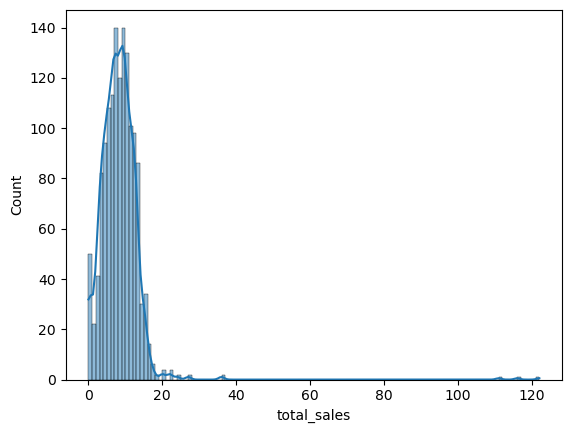

In [343]:
sns.histplot(web_nettoye, x='total_sales', binwidth=1, kde=True, kde_kws={'bw_adjust': 0.5})

C'est bon pour cette partie !

In [345]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
sku_vus = set()  # pour stocker les SKU uniques
doublons = []

for i, row in web_nettoye.iterrows():
    sku_value = row['sku']  # on suppose que la colonne s'appelle 'sku'
    
    # vérifier doublon
    if sku_value in sku_vus:
        print(f'Doublon trouvé à la ligne {i} : {sku_value}')
        doublons.append(sku_value)
    else:
        sku_vus.add(sku_value)

Doublon trouvé à la ligne 56 : 12869
Doublon trouvé à la ligne 74 : 13809
Doublon trouvé à la ligne 109 : 15758
Doublon trouvé à la ligne 117 : 13766
Doublon trouvé à la ligne 137 : 16580
Doublon trouvé à la ligne 145 : 13557
Doublon trouvé à la ligne 188 : 15690
Doublon trouvé à la ligne 197 : 11586
Doublon trouvé à la ligne 209 : 16044
Doublon trouvé à la ligne 210 : 14507
Doublon trouvé à la ligne 217 : 16238
Doublon trouvé à la ligne 218 : 14768
Doublon trouvé à la ligne 222 : 15324
Doublon trouvé à la ligne 228 : 15895
Doublon trouvé à la ligne 232 : 15707
Doublon trouvé à la ligne 233 : 15269
Doublon trouvé à la ligne 237 : 15038
Doublon trouvé à la ligne 239 : 14700
Doublon trouvé à la ligne 245 : 15448
Doublon trouvé à la ligne 248 : 13435
Doublon trouvé à la ligne 262 : 14661
Doublon trouvé à la ligne 271 : 13958
Doublon trouvé à la ligne 275 : 15921
Doublon trouvé à la ligne 278 : 15328
Doublon trouvé à la ligne 284 : 13849
Doublon trouvé à la ligne 286 : 15577
Doublon trouvé

Oui, il y a des doublons !!

On va voir si les lignes sont égales !!

In [347]:
web_doublons = web_nettoye[web_nettoye['sku'].isin(doublons)]

# Vérifier les doublons dans ce DataFrame
for i, row in web_doublons.iterrows():
    sku_value = row['sku']
    
    # Comparer toutes les colonnes pour ce sku
    group = web_doublons[web_doublons['sku'] == sku_value]
    
    # Si toutes les colonnes (sauf 'sku') sont identiques, c'est un vrai doublon, sinon c'est un faux !
    if (group.drop(columns='sku').nunique() <= 1).all():
        print(f"Vrai doublon trouvé pour SKU {sku_value}, lignes {list(group.index)}")
    else:
        print(f"Faux doublon pour SKU {sku_value}, lignes {list(group.index)}")

Faux doublon pour SKU 11862, lignes [0, 1001]
Faux doublon pour SKU 16057, lignes [1, 1436]
Faux doublon pour SKU 14692, lignes [2, 336]
Faux doublon pour SKU 16295, lignes [3, 1096]
Faux doublon pour SKU 15328, lignes [4, 278]
Faux doublon pour SKU 15471, lignes [5, 919]
Faux doublon pour SKU 16515, lignes [6, 866]
Faux doublon pour SKU 16246, lignes [7, 576]
Faux doublon pour SKU 13572, lignes [9, 806]
Faux doublon pour SKU 16513, lignes [10, 435]
Faux doublon pour SKU 16585, lignes [11, 1305]
Faux doublon pour SKU 16269, lignes [12, 418]
Faux doublon pour SKU 15526, lignes [13, 1162]
Faux doublon pour SKU 12869, lignes [14, 56]
Faux doublon pour SKU 15575, lignes [15, 858]
Faux doublon pour SKU 11586, lignes [16, 197]
Faux doublon pour SKU 14338, lignes [17, 1217]
Faux doublon pour SKU 15425, lignes [18, 299]
Faux doublon pour SKU 16560, lignes [19, 699]
Faux doublon pour SKU 15361, lignes [21, 804]
Faux doublon pour SKU 13809, lignes [22, 74]
Faux doublon pour SKU 11587, lignes [23

Ah bah ça alors, ce n'est que des faux doublons !

On va regarder quelles sont les colonnes qui posent problèmes :

In [350]:
for sku, group in web_doublons.groupby('sku'):
    # On enlève la colonne SKU pour comparer les autres
    g = group.drop(columns='sku')
    
    # Identifier les colonnes où il y a plus d'une valeur unique
    colonnes_diff = g.columns[g.nunique() > 1].tolist()
    
    print(f"\nSKU {sku} — colonnes différentes : {colonnes_diff}")
    
    # Afficher uniquement les colonnes concernées
    if colonnes_diff:
        print(g[colonnes_diff])
    else:
        print(" -> Toutes les colonnes sont identiques (vrai doublon)")


SKU 10014 — colonnes différentes : ['guid', 'post_type']
                                                   guid   post_type
668   https://www.bottle-neck.fr/?post_type=product&...     product
1030  https://www.bottle-neck.fr/wp-content/uploads/...  attachment

SKU 10459 — colonnes différentes : ['guid', 'post_type']
                                                  guid   post_type
748  https://www.bottle-neck.fr/?post_type=product&...     product
887  https://www.bottle-neck.fr/wp-content/uploads/...  attachment

SKU 10775 — colonnes différentes : ['guid', 'post_type']
                                                   guid   post_type
802   https://www.bottle-neck.fr/?post_type=product&...     product
1317  https://www.bottle-neck.fr/wp-content/uploads/...  attachment

SKU 10814 — colonnes différentes : ['guid', 'post_type']
                                                  guid   post_type
520  https://www.bottle-neck.fr/wp-content/uploads/...  attachment
860  https://www.bottle-n

Les colonnes différentes sont systématiquement guid et post_type

On va vérifier : 

In [352]:
web_doublons = web_doublons.drop(columns=['guid', 'post_type'])

In [353]:
# Pour chaque SKU en doublon
for sku, group in web_doublons.groupby('sku'):
    # On enlève la colonne SKU pour comparer les autres
    g = group.drop(columns='sku')
    
    # Identifier les colonnes où il y a plus d'une valeur unique
    colonnes_diff = g.columns[g.nunique() > 1].tolist()
    
    print(f"\nSKU {sku} — colonnes différentes : {colonnes_diff}")
    
    # Afficher uniquement les colonnes concernées
    if colonnes_diff:
        print(g[colonnes_diff])
    else:
        print(" -> Toutes les colonnes sont identiques (vrai doublon)")


SKU 10014 — colonnes différentes : []
 -> Toutes les colonnes sont identiques (vrai doublon)

SKU 10459 — colonnes différentes : []
 -> Toutes les colonnes sont identiques (vrai doublon)

SKU 10775 — colonnes différentes : []
 -> Toutes les colonnes sont identiques (vrai doublon)

SKU 10814 — colonnes différentes : []
 -> Toutes les colonnes sont identiques (vrai doublon)

SKU 11049 — colonnes différentes : []
 -> Toutes les colonnes sont identiques (vrai doublon)

SKU 11225 — colonnes différentes : []
 -> Toutes les colonnes sont identiques (vrai doublon)

SKU 11258 — colonnes différentes : []
 -> Toutes les colonnes sont identiques (vrai doublon)

SKU 11277 — colonnes différentes : []
 -> Toutes les colonnes sont identiques (vrai doublon)

SKU 11467 — colonnes différentes : []
 -> Toutes les colonnes sont identiques (vrai doublon)

SKU 11585 — colonnes différentes : []
 -> Toutes les colonnes sont identiques (vrai doublon)

SKU 11586 — colonnes différentes : []
 -> Toutes les colonn

Super !

On va faire pareil avec web_nettoye. On va supprimer guid et post_types puis supprimer les lignes en double

In [355]:
web_nettoye = web_nettoye.drop(columns=['guid', 'post_type'])

In [356]:
skus = []
lignes_a_supprimer = []

for i, row in web_nettoye.iterrows():
    sku_value = row['sku']
    
    if sku_value in skus:
        lignes_a_supprimer.append(i)   # on marque la ligne à supprimer
    else:
        skus.append(sku_value)

# Maintenant on supprime toutes les lignes en doublon
web_nettoye = web_nettoye.drop(index=lignes_a_supprimer)

In [357]:
#Le nombre de valeurs présentes dans chacune des colonnes
web_nettoye.count(axis=0, numeric_only=False)

sku                  714
average_rating       714
total_sales          714
tax_status           361
post_author          714
post_date            714
post_date_gmt        714
product_type         714
post_title           714
post_excerpt         361
post_status          714
comment_status       714
ping_status          714
post_name            714
post_modified        714
post_modified_gmt    714
post_parent          714
menu_order           714
post_mime_type       353
comment_count        714
dtype: int64

In [358]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:

#1 - Créer un dataframe avec uniquement les lignes sans code article

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes

#3 - Que constatez-vous?

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [360]:
#Dimension du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(liaison.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [361]:
#Nombre d'observations
liaison.count(axis=0, numeric_only=False)

id_web        734
product_id    825
dtype: int64

In [362]:
#Nombre de caractéristiques

In [363]:
#Nombre de caractéristiques
liaison.dtypes

id_web        object
product_id     int64
dtype: object

In [364]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
product_id_vus = set()  # pour stocker les product_ids uniques
doublons_product_id = []

for i, row in liaison.iterrows():
    product_id = row['product_id']  
    
    # vérifier doublon
    if product_id  in product_id_vus:
        print(f'Doublon trouvé à la ligne {i} : {product_id}')
        doublons_product_id.append(product_id)
    else:
        product_id_vus.add( product_id)

Pas de doublons dans product_id !

In [366]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
id_web_vus = set()  
doublons_id_web = []

for i, row in liaison.iterrows():
    id_web = row['id_web'] 
    
    # vérifier doublon
    if id_web in id_web_vus:
        print(f'Doublon trouvé à la ligne {i} : {id_web}')
        doublons_id_web.append(id_web)
    else:
        id_web_vus.add(id_web)

Doublon trouvé à la ligne 49 : nan
Doublon trouvé à la ligne 50 : nan
Doublon trouvé à la ligne 119 : nan
Doublon trouvé à la ligne 131 : nan
Doublon trouvé à la ligne 151 : nan
Doublon trouvé à la ligne 184 : nan
Doublon trouvé à la ligne 185 : nan
Doublon trouvé à la ligne 234 : nan
Doublon trouvé à la ligne 238 : nan
Doublon trouvé à la ligne 239 : nan
Doublon trouvé à la ligne 242 : nan
Doublon trouvé à la ligne 246 : nan
Doublon trouvé à la ligne 292 : nan
Doublon trouvé à la ligne 318 : nan
Doublon trouvé à la ligne 319 : nan
Doublon trouvé à la ligne 320 : nan
Doublon trouvé à la ligne 321 : nan
Doublon trouvé à la ligne 322 : nan
Doublon trouvé à la ligne 340 : nan
Doublon trouvé à la ligne 352 : nan
Doublon trouvé à la ligne 356 : nan
Doublon trouvé à la ligne 384 : nan
Doublon trouvé à la ligne 396 : nan
Doublon trouvé à la ligne 416 : nan
Doublon trouvé à la ligne 449 : nan
Doublon trouvé à la ligne 469 : nan
Doublon trouvé à la ligne 472 : nan
Doublon trouvé à la ligne 486 

Non il n y a pas de doublons dans id_web, il y a toutefois des valeurs vides. Ce n'est pas important car elles seront exclues par le merge !

In [368]:
#Avons-nous des articles sans correspondance?


Oui nécessairement, puisqu'il y a 825 product_id et 734 id_web. Voir plus haut.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [372]:
erp_nettoye.columns

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'in_stock',
       'purchase_price'],
      dtype='object')

In [373]:
erp_nettoye.count()

product_id        825
onsale_web        825
price             825
stock_quantity    825
in_stock          825
purchase_price    825
dtype: int64

In [374]:
liaison.count()

id_web        734
product_id    825
dtype: int64

In [375]:
#Fusion des fichiers df_erp et df_liaison
erp_nettoye_liaison = pd.merge(erp_nettoye, liaison, how='inner', on='product_id')

In [376]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
erp_nettoye_liaison.count()

product_id        825
onsale_web        825
price             825
stock_quantity    825
in_stock          825
purchase_price    825
id_web            734
dtype: int64

Oui, il y a des product_id sans id_web !

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [379]:
web_nettoye.columns

Index(['sku', 'average_rating', 'total_sales', 'tax_status', 'post_author',
       'post_date', 'post_date_gmt', 'product_type', 'post_title',
       'post_excerpt', 'post_status', 'comment_status', 'ping_status',
       'post_name', 'post_modified', 'post_modified_gmt', 'post_parent',
       'menu_order', 'post_mime_type', 'comment_count'],
      dtype='object')

In [380]:
web_nettoye = web_nettoye.rename(columns={'sku': 'id_web'})

In [381]:
#Fusionner les datasets df_merge et df_web
erp_nettoye_web_nettoye_liaison = pd.merge(erp_nettoye_liaison, web_nettoye, how='inner', on='id_web')

In [382]:
#Avons-nous des lignes sans correspondance?
erp_nettoye_web_nettoye_liaison.count()

product_id           714
onsale_web           714
price                714
stock_quantity       714
in_stock             714
purchase_price       714
id_web               714
average_rating       714
total_sales          714
tax_status           361
post_author          714
post_date            714
post_date_gmt        714
product_type         714
post_title           714
post_excerpt         361
post_status          714
comment_status       714
ping_status          714
post_name            714
post_modified        714
post_modified_gmt    714
post_parent          714
menu_order           714
post_mime_type       353
comment_count        714
dtype: int64

Non !! 

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

In [386]:
erp_nettoye_web_nettoye_liaison.columns

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'in_stock',
       'purchase_price', 'id_web', 'average_rating', 'total_sales',
       'tax_status', 'post_author', 'post_date', 'post_date_gmt',
       'product_type', 'post_title', 'post_excerpt', 'post_status',
       'comment_status', 'ping_status', 'post_name', 'post_modified',
       'post_modified_gmt', 'post_parent', 'menu_order', 'post_mime_type',
       'comment_count'],
      dtype='object')

<Axes: >

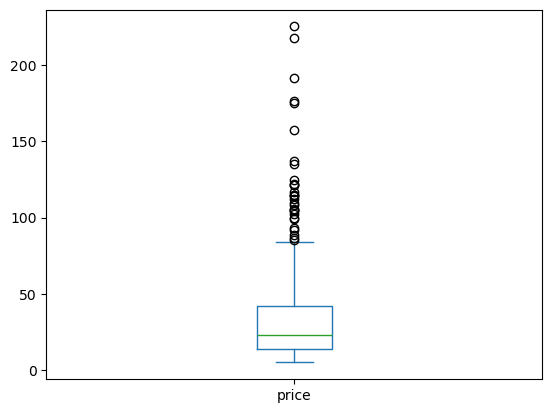

In [387]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
erp_nettoye_web_nettoye_liaison['price'].plot.box()

In [388]:
import plotly.express as px

#Autre méthode avec plotly express
fig = px.box(erp_nettoye, y="price")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [391]:
#Calculer la moyenne du prix
moyenne_prix = erp_nettoye_web_nettoye_liaison['price'].mean()
print(moyenne_prix)

32.33368347338936


In [392]:
#Calculer l'écart-type du prix
ecart_type_prix = erp_nettoye_web_nettoye_liaison['price'].std()
print(ecart_type_prix)

27.5963324191972


In [393]:
#Calculer le Z-score
erp_nettoye_web_nettoye_liaison['z_price'] = (
    (erp_nettoye_web_nettoye_liaison['price'] - moyenne_prix) / ecart_type_prix
)

<Axes: xlabel='price', ylabel='z_price'>

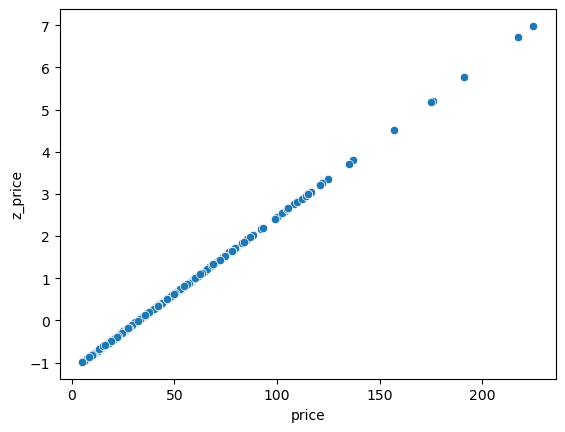

In [394]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
sns.scatterplot(erp_nettoye_web_nettoye_liaison, x = 'price', y='z_price')

Environ 110

Pour être plus précis : 

In [397]:
erp_nettoye_web_nettoye_liaison_inf_trois = erp_nettoye_web_nettoye_liaison[erp_nettoye_web_nettoye_liaison['z_price'] > 3]

In [398]:
erp_nettoye_web_nettoye_liaison_inf_trois['price'].min()

116.4

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [400]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
erp_nettoye_web_nettoye_liaison.describe()

,product_id,price,stock_quantity,purchase_price,average_rating,total_sales,post_author,post_parent,menu_order,comment_count,z_price
count,714.00,714.00,714.00,714.00,714.00,714.00,714.00,714.00,714.00,714.00,714.00
mean,5032.56,32.33,23.45,16.90,0.00,8.52,2.00,0.00,0.00,0.00,-0.00
std,790.51,27.60,22.22,14.83,0.00,8.15,0.04,0.00,0.00,0.00,1.00
min,3847.00,5.20,0.00,2.74,0.00,0.00,1.00,0.00,0.00,0.00,-0.98
25%,4280.25,14.06,9.00,7.24,0.00,5.00,2.00,0.00,0.00,0.00,-0.66
50%,4796.00,23.45,20.00,12.30,0.00,8.00,2.00,0.00,0.00,0.00,-0.32
75%,5710.50,42.08,30.00,22.03,0.00,11.00,2.00,0.00,0.00,0.00,0.35
max,7338.00,225.00,145.00,137.81,0.00,122.00,2.00,0.00,0.00,0.00,6.98


In [401]:
# Outliers

On choisira simplement la méthode de la boite à moustache où la limite supérieure = Q3 + 1,5 * (Q3 -Q2).

In [403]:
fig = px.box(erp_nettoye, y="price")
fig.show()

Selon cette définition, les valeurs aberrantes commencent au-delà de 83 euros. Ce qui semble relativement cohérent.

In [405]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
erp_nettoye_web_nettoye_liaison_outliers = erp_nettoye_web_nettoye_liaison[erp_nettoye_web_nettoye_liaison['price'] > 83]

In [406]:
Nb_outliers = len(erp_nettoye_web_nettoye_liaison_outliers)
Total_produit = len(erp_nettoye_web_nettoye_liaison)

Proportion_outlier = Nb_outliers / Total_produit * 100
print(Proportion_outlier)

4.481792717086835


In [407]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?

La définition d'un outlier ou valeur aberrante dépend du contexte, pas seulement d'un calcul.

Pour valider le caractère aberrant des prix de certaines bouteilles, il serait pertinent de comparer ces valeurs à des sources externes pour voir si de tels prix existent. Je pense que oui.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [411]:
erp_nettoye_web_nettoye_liaison.columns

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'in_stock',
       'purchase_price', 'id_web', 'average_rating', 'total_sales',
       'tax_status', 'post_author', 'post_date', 'post_date_gmt',
       'product_type', 'post_title', 'post_excerpt', 'post_status',
       'comment_status', 'ping_status', 'post_name', 'post_modified',
       'post_modified_gmt', 'post_parent', 'menu_order', 'post_mime_type',
       'comment_count', 'z_price'],
      dtype='object')

In [412]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
erp_nettoye_web_nettoye_liaison['CA'] = erp_nettoye_web_nettoye_liaison['price'] * erp_nettoye_web_nettoye_liaison['total_sales']



In [413]:
#Calculer la somme de la colonne "ca_par_article"

#Ce résultat correspond au chiffre d'affaire du site web

erp_nettoye_web_nettoye_liaison['CA'].sum()

153748.1

In [414]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
erp_nettoye_web_nettoye_liaison = erp_nettoye_web_nettoye_liaison.sort_values(by='CA', ascending = False)
#Réinitialiser l'index du dataset par un reset_index
erp_nettoye_web_nettoye_liaison.reset_index()
#Afficher les 20 premiers articles en CA
erp_nettoye_web_nettoye_liaison.head(20)



,product_id,onsale_web,price,stock_quantity,in_stock,purchase_price,id_web,average_rating,total_sales,tax_status,...,ping_status,post_name,post_modified,post_modified_gmt,post_parent,menu_order,post_mime_type,comment_count,z_price,CA
76,4150,True,59.00,123,True,35.45,1366,0.00,116.00,NaN,...,closed,champagne-mailly-grand-cru-intemporelle-2010,2020-08-26 18:05:02,2020-08-26 16:05:02,0.00,0.00,image/jpeg,0.00,0.97,6844.00
199,4352,True,225.00,0,False,137.81,15940,0.00,11.00,NaN,...,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,0.00,0.00,image/jpeg,0.00,6.98,2475.00
321,4726,True,12.70,0,False,6.82,14950,0.00,122.00,NaN,...,closed,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,0.00,0.00,image/jpeg,0.00,-0.71,1549.40
445,5067,True,59.90,3,True,30.95,15346,0.00,22.00,NaN,...,closed,albert-mann-pinot-noir-grand-h-2017,2020-02-13 17:00:01,2020-02-13 16:00:01,0.00,0.00,image/jpeg,0.00,1.00,1317.80
450,5379,True,11.10,33,True,5.68,14561,0.00,111.00,NaN,...,closed,argentine-mendoza-alamos-torrontes-2017,2020-07-11 14:00:03,2020-07-11 12:00:03,0.00,0.00,image/jpeg,0.00,-0.77,1232.10
587,5892,True,191.30,98,True,116.06,14983,0.00,6.00,NaN,...,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,0.00,0.00,image/jpeg,0.00,5.76,1147.80
200,4353,True,79.50,127,True,45.91,12587,0.00,14.00,taxable,...,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,0.00,0.00,NaN,0.00,1.71,1113.00
582,5826,True,41.20,34,True,21.71,15325,0.00,20.00,NaN,...,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,0.00,0.00,image/jpeg,0.00,0.32,824.00
653,6212,True,115.00,16,True,59.42,13996,0.00,7.00,NaN,...,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,0.00,0.00,image/jpeg,0.00,3.00,805.00
438,5026,True,86.80,101,True,50.13,13913,0.00,9.00,NaN,...,closed,champagne-agrapart-fils-mineral-extra-brut-bla...,2020-05-11 14:35:02,2020-05-11 12:35:02,0.00,0.00,image/jpeg,0.00,1.97,781.20


In [415]:
#Graphique en barre des 20 premiers articles avec plotly express

# Trier le DataFrame par CA décroissant et prendre les 20 premiers
top20 = erp_nettoye_web_nettoye_liaison.sort_values(by='CA', ascending=False).head(20)

# Créer le graphique en barres
fig = px.bar(
    top20, 
    x='post_title',    # ou 'product_id' si tu préfères
    y='CA',
    text='CA',         # afficher la valeur sur chaque barre
    labels={'post_title': 'Produit', 'CA': 'Chiffre d\'affaires'},
    title='Top 20 des articles par CA'
)

fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_title='Chiffre d\'affaires',
    xaxis_title='Produit'
)

fig.show()

Pour la présentation on va le refaire en enlevant les légendes de colonnes :

In [417]:
# Graphique en barre des 20 premiers articles avec plotly express

# Trier le DataFrame par CA décroissant et prendre les 20 premiers
top20 = erp_nettoye_web_nettoye_liaison.sort_values(by='CA', ascending=False).head(20)

# Créer le graphique en barres (sans texte sur les barres et sans labels sous les barres)
fig = px.bar(
    top20, 
    x='post_title',
    y='CA',
    labels={'post_title': 'Produit', 'CA': 'Chiffre d\'affaires'},
    title='Top 20 des articles par CA'
)

# Suppression des labels sous les barres
fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_title='Chiffre d\'affaires',
    xaxis_title='Produit',
    xaxis_showticklabels=False    # <-- enlève les légendes sous les barres
)

# S’assurer qu’aucun texte n’apparaît sur les barres
fig.update_traces(text=None)

fig.show()

In [418]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
erp_nettoye_web_nettoye_liaison['%CA'] = (erp_nettoye_web_nettoye_liaison['CA'] / erp_nettoye_web_nettoye_liaison['CA'].sum()) * 100


In [419]:
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée

erp_nettoye_web_nettoye_liaison_filtre = erp_nettoye_web_nettoye_liaison.sort_values(by = '%CA', ascending = True)

# Créer la colonne de pourcentage cumulé
erp_nettoye_web_nettoye_liaison_filtre['%CA_cumul'] = erp_nettoye_web_nettoye_liaison_filtre['%CA'].cumsum()


In [420]:
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA

erp_nettoye_web_nettoye_liaison_80 = erp_nettoye_web_nettoye_liaison_filtre[erp_nettoye_web_nettoye_liaison_filtre['%CA_cumul'] > 80]

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web

Proportion_art_80_CA = len(erp_nettoye_web_nettoye_liaison_80)/ len(erp_nettoye_web_nettoye_liaison) * 100

In [421]:
print(Proportion_art_80_CA)

4.621848739495799


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [423]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
erp_nettoye_web_nettoye_liaison_tri_quant = erp_nettoye_web_nettoye_liaison.sort_values(by = 'total_sales', ascending= False)
#Réinitialiser l'index du dataset par un reset_index
erp_nettoye_web_nettoye_liaison_tri_quant.reset_index()
#Afficher les 20 premiers articles en quantité
erp_nettoye_web_nettoye_liaison_tri_quant.head(20)



,product_id,onsale_web,price,stock_quantity,in_stock,purchase_price,id_web,average_rating,total_sales,tax_status,...,post_name,post_modified,post_modified_gmt,post_parent,menu_order,post_mime_type,comment_count,z_price,CA,%CA
321,4726,True,12.70,0,False,6.82,14950,0.00,122.00,NaN,...,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,0.00,0.00,image/jpeg,0.00,-0.71,1549.40,1.01
76,4150,True,59.00,123,True,35.45,1366,0.00,116.00,NaN,...,champagne-mailly-grand-cru-intemporelle-2010,2020-08-26 18:05:02,2020-08-26 16:05:02,0.00,0.00,image/jpeg,0.00,0.97,6844.00,4.45
450,5379,True,11.10,33,True,5.68,14561,0.00,111.00,NaN,...,argentine-mendoza-alamos-torrontes-2017,2020-07-11 14:00:03,2020-07-11 12:00:03,0.00,0.00,image/jpeg,0.00,-0.77,1232.10,0.80
365,4867,True,9.90,121,True,4.86,16148,0.00,36.00,taxable,...,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,2020-08-27 09:30:15,2020-08-27 07:30:15,0.00,0.00,NaN,0.00,-0.81,356.40,0.23
122,4203,True,9.90,74,True,5.01,15415,0.00,27.00,taxable,...,mas-laval-igp-pays-herault-pampres-blanc-2018,2020-07-11 16:45:03,2020-07-11 14:45:03,0.00,0.00,NaN,0.00,-0.81,267.30,0.17
175,4275,True,14.90,62,True,7.78,14864,0.00,24.00,taxable,...,i-fabbri-chianti-classico-lamole-2017,2020-08-22 14:35:02,2020-08-22 12:35:02,0.00,0.00,NaN,0.00,-0.63,357.60,0.23
445,5067,True,59.90,3,True,30.95,15346,0.00,22.00,NaN,...,albert-mann-pinot-noir-grand-h-2017,2020-02-13 17:00:01,2020-02-13 16:00:01,0.00,0.00,image/jpeg,0.00,1.00,1317.80,0.86
265,4647,True,28.50,45,True,14.14,16525,0.00,22.00,taxable,...,bernard-baudry-chinon-rouge-croix-boissee-2017,2020-07-31 09:31:39,2020-07-31 07:31:39,0.00,0.00,NaN,0.00,-0.14,627.00,0.41
582,5826,True,41.20,34,True,21.71,15325,0.00,20.00,NaN,...,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,0.00,0.00,image/jpeg,0.00,0.32,824.00,0.54
645,6129,True,5.20,68,True,2.74,14570,0.00,20.00,taxable,...,moulin-de-gassac-igp-pays-dherault-guilhem-bla...,2020-08-26 15:55:02,2020-08-26 13:55:02,0.00,0.00,NaN,0.00,-0.98,104.00,0.07


In [424]:
# graphique en barre des 20 premiers articles par sales.

# Trier le DataFrame par total_sales décroissant et prendre les 20 premiers
top20_quant = erp_nettoye_web_nettoye_liaison.sort_values(by='total_sales', ascending=False).head(20)

# Créer le graphique en barres
fig = px.bar(
    top20_quant,
    x='post_title',        # nom des produits
    y='total_sales',       # valeur des ventes
    text='total_sales',    # afficher le nombre de ventes sur chaque barre
    labels={'post_title': 'Produit', 'total_sales': 'Total des ventes'},
    title='Top 20 des articles par total_sales'
)

fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_title='Total des ventes',
    xaxis_title='Produit'
)

fig.show()


Pour la présentation, on va le refaire en enlevant les légendes de colonnes :

In [426]:
# Graphique en barre des 20 premiers articles par total_sales

# Trier le DataFrame par total_sales décroissant et prendre les 20 premiers
top20_quant = erp_nettoye_web_nettoye_liaison.sort_values(by='total_sales', ascending=False).head(20)

# Créer le graphique en barres (sans texte sur les barres)
fig = px.bar(
    top20_quant,
    x='post_title',
    y='total_sales',
    labels={'post_title': 'Produit', 'total_sales': 'Total des ventes'},
    title='Top 20 des articles par total_sales'
)

# Suppression des labels sous les barres + mise en forme
fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_title='Total des ventes',
    xaxis_title='Produit',
    xaxis_showticklabels=False    # <-- enlève les noms sous les barres
)

# S'assurer qu'aucun texte n'apparait sur les barres
fig.update_traces(text=None)

fig.show()


In [427]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
erp_nettoye_web_nettoye_liaison['%total_sales'] = (erp_nettoye_web_nettoye_liaison['total_sales'] / erp_nettoye_web_nettoye_liaison['total_sales'].sum()) * 100
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
erp_nettoye_web_nettoye_liaison_filtre_sales = erp_nettoye_web_nettoye_liaison.sort_values(by = '%total_sales', ascending = True)
erp_nettoye_web_nettoye_liaison_filtre_sales['%total_sales_cumul'] = erp_nettoye_web_nettoye_liaison_filtre_sales['%total_sales'].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
erp_nettoye_web_nettoye_liaison_filtre_sales_80 = erp_nettoye_web_nettoye_liaison_filtre_sales[erp_nettoye_web_nettoye_liaison_filtre_sales['%total_sales_cumul'] > 80]
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
Proportion_art_80_sales = len(erp_nettoye_web_nettoye_liaison_filtre_sales_80)/ len(erp_nettoye_web_nettoye_liaison) * 100
print(Proportion_art_80_sales)

7.9831932773109235


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [429]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np
#Création de la colonne Rotation de stock
erp_nettoye_web_nettoye_liaison['Mois_stock'] = (erp_nettoye_web_nettoye_liaison['stock_quantity'] / erp_nettoye_web_nettoye_liaison['total_sales']).round(1)
#Remplacement des "inf" par 0
erp_nettoye_web_nettoye_liaison['Mois_stock'] = (
    erp_nettoye_web_nettoye_liaison['Mois_stock']
    .clip(lower=0, upper=None)
)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
erp_nettoye_web_nettoye_liaison['Mois_stock'] = erp_nettoye_web_nettoye_liaison['Mois_stock'].replace([np.inf, -np.inf], 0)
erp_nettoye_web_nettoye_liaison = erp_nettoye_web_nettoye_liaison.sort_values(by='Mois_stock', ascending=False)
erp_nettoye_web_nettoye_liaison = erp_nettoye_web_nettoye_liaison.reset_index(drop=True)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock

top20_mois_stock = erp_nettoye_web_nettoye_liaison.head(20)

# Créer le graphique en barres
fig = px.bar(
    top20_mois_stock,
    x='post_title',        # nom des produits
    y='Mois_stock',       # valeur des ventes
    text='Mois_stock',    # afficher le nombre de ventes sur chaque barre
    labels={'post_title': 'Produit', 'mois de stock': 'Total mois de stock'},
    title='Top 20 des articles par mois de stock'
)

fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_title='Mois de stock',
    xaxis_title='Produit'
)

fig.show()

Pour la présentation, on va inverser les axes et enlever les légendes qui gênent la lecture : 

In [431]:
# Graphique en barres horizontales du Top 20 des produits avec le plus de mois de stock

top20_mois_stock = erp_nettoye_web_nettoye_liaison.head(20)

# Créer le graphique en barres horizontales (axes inversés)
fig = px.bar(
    top20_mois_stock,
    x='Mois_stock',        # valeur affichée en longueur (axe horizontal)
    y='post_title',        # catégories sur l'axe vertical
    labels={'post_title': 'Produit', 'Mois_stock': 'Mois de stock'},
    title='Top 20 des articles par mois de stock'
)

# Supprimer les labels sous les barres + mise en forme
fig.update_layout(
    yaxis_title='Produit',
    xaxis_title='Mois de stock',
    yaxis_showticklabels=False,   # <-- enlève les noms des produits
)

# Supprimer le texte sur les barres
fig.update_traces(text=None)
fig.update_layout(
    width=500,     # largeur courte
    height=1000    # hauteur longue
)
fig.show()

In [432]:
top20_mois_stock[['post_title', 'Mois_stock']].head(5)

,post_title,Mois_stock
0,Champagne Gosset Grand Millésime 2006,31.20
1,Champagne Gosset Célébris Vintage 2007,27.60
2,Champagne Egly-Ouriet Premier Cru Les Vignes d...,27.00
3,Champagne Egly-Ouriet Grand Cru Brut Tradition,25.00
4,Champagne Mailly Grand Cru Brut Rosé,23.70


In [433]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
erp_nettoye_web_nettoye_liaison['valorisation'] = erp_nettoye_web_nettoye_liaison['price'] * erp_nettoye_web_nettoye_liaison['stock_quantity']
#Calculer la somme de la colonne "Valorisation_stock_euros"
somme_valorisation = erp_nettoye_web_nettoye_liaison['valorisation'].sum()
print(somme_valorisation)

494637.9


In [434]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
valorisation_stock = erp_nettoye_web_nettoye_liaison['stock_quantity'].sum()
print(valorisation_stock)

16740


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [436]:
erp_nettoye_web_nettoye_liaison.columns

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'in_stock',
       'purchase_price', 'id_web', 'average_rating', 'total_sales',
       'tax_status', 'post_author', 'post_date', 'post_date_gmt',
       'product_type', 'post_title', 'post_excerpt', 'post_status',
       'comment_status', 'ping_status', 'post_name', 'post_modified',
       'post_modified_gmt', 'post_parent', 'menu_order', 'post_mime_type',
       'comment_count', 'z_price', 'CA', '%CA', '%total_sales', 'Mois_stock',
       'valorisation'],
      dtype='object')

In [437]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
erp_nettoye_web_nettoye_liaison['Prix_HT'] = erp_nettoye_web_nettoye_liaison['price'] * 0.8
#Création de la colonne Taux de marge
erp_nettoye_web_nettoye_liaison['Taux_marge'] = ((erp_nettoye_web_nettoye_liaison['Prix_HT'] - erp_nettoye_web_nettoye_liaison['purchase_price']) / erp_nettoye_web_nettoye_liaison['Prix_HT']) * 100
#Afficher le prix minimum de la colonne "taux_marge"
print(erp_nettoye_web_nettoye_liaison['Taux_marge'].min())
#Afficher le prix maximum de la colonne "taux_marge"
print(erp_nettoye_web_nettoye_liaison['Taux_marge'].max())

-665.6126482213438
45.58


In [438]:
#Affichage de la ligne avec un taux de marge inférieur à 0
neg_marge = erp_nettoye_web_nettoye_liaison.loc[
    erp_nettoye_web_nettoye_liaison['Taux_marge'] < 0
]

print(neg_marge)

     product_id  onsale_web  price  stock_quantity  in_stock  purchase_price  \
691        4355        True  12.65              97      True           77.48   

    id_web  average_rating  total_sales tax_status  ...  post_mime_type  \
691  12589            0.00         0.00    taxable  ...             NaN   

    comment_count z_price   CA  %CA %total_sales Mois_stock valorisation  \
691          0.00   -0.71 0.00 0.00         0.00       0.00      1227.05   

    Prix_HT Taux_marge  
691   10.12    -665.61  

[1 rows x 34 columns]


In [439]:
#Création d'un dataframe avec les taux positifs
pos_marge = erp_nettoye_web_nettoye_liaison.loc[
    erp_nettoye_web_nettoye_liaison['Taux_marge'] > 0
]
#Afficher le prix minimum de la colonne "taux_marge"
print(pos_marge['Taux_marge'].min())
#Afficher le prix maximum de la colonne "taux_marge"
print(pos_marge['Taux_marge'].max())
#Afficher la moyenne de la colonne "taux_marge"
print(pos_marge['Taux_marge'].mean())

19.561068702290083
45.58
35.231736144419834


In [440]:
#Création d'un dataframe avec le taux de marge moyen par type de produit

taux_moyen_par_produit = pos_marge.groupby('product_type')['Taux_marge'].mean().reset_index()
taux_moyen_par_produit['Taux_marge'] = taux_moyen_par_produit['Taux_marge'].round(1)
print(taux_moyen_par_produit)

#Affichage dans un graphique du taux de marge par type de produit


    product_type  Taux_marge
0          Autre       33.50
1      Champagne       25.50
2         Cognac       42.80
3            Gin       40.40
4  Huile d'olive       21.90
5            Vin       35.40
6         Whisky       42.60


In [441]:
#Affichage dans un graphique du taux de marge par type de produit
import plotly.express as px


fig = px.bar(
    taux_moyen_par_produit,     
    x='product_type',           
    y='Taux_marge',             
    text='Taux_marge',           
    labels={'product_type': 'Type de produit', 'Taux_marge': 'Taux de marge (%)'},
    title='Taux de marge moyen par type de produit'
)


fig.update_layout(
    xaxis_tickangle=-45,          
    yaxis_title='Taux de marge (%)',
    xaxis_title='Type de produit',
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)


fig.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

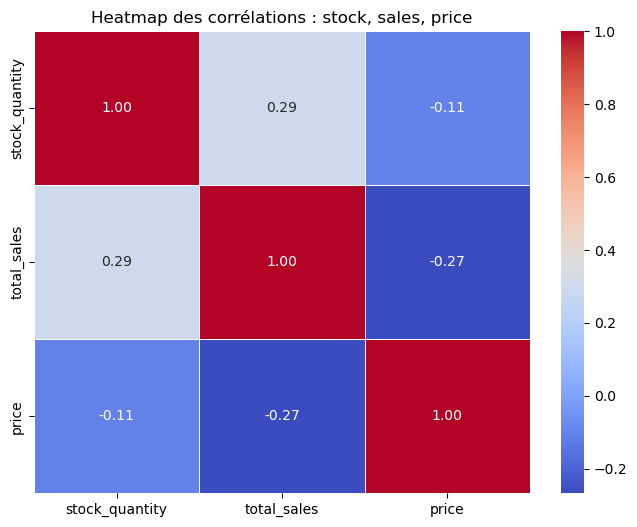

In [443]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap

# Sélection des variables
df_corr = erp_nettoye_web_nettoye_liaison[['stock_quantity', 'total_sales', 'price']]

# Calcul de la matrice de corrélation
corr = df_corr.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,      # Retirer cette ligne si vous voulez la heatmap complète
    annot=True,
    cmap='coolwarm',
    linewidths=.5,
    fmt=".2f"
)

plt.title("Heatmap des corrélations : stock, sales, price")
plt.show()

In [444]:
#Que peut-on conclure des corrélations ?

Le prix de vente est négativement corrélé au nombre de ventes (déjà vu, voir plus haut), ce qui est normal et cohérent (les articles chers sont peu vendus). 

Par contre, le nombre de ventes est positivement corrélé aux quantités en stock, ce qui est une bonne chose. 

Encore une fois, logiquement les quantités en stock ne sont pas corrélées au prix. 

On va également sortir la demi-heatmap pour la présentation :

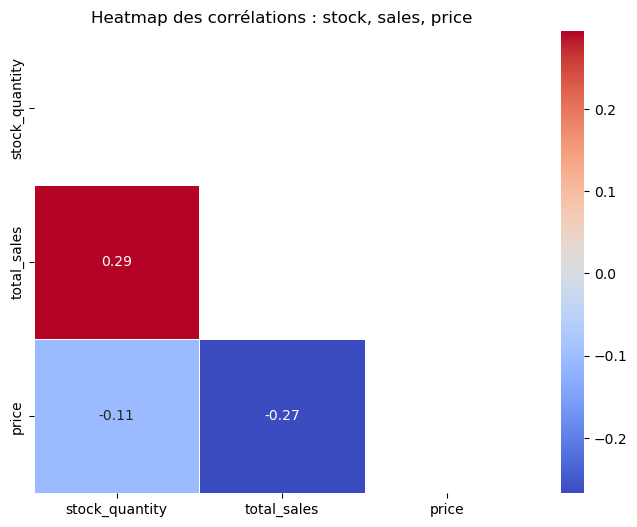

In [447]:
# Sélection des variables
df_corr = erp_nettoye_web_nettoye_liaison[['stock_quantity', 'total_sales', 'price']]

# Calcul de la matrice de corrélation
corr = df_corr.corr()

# Création du mask : on cache la moitié supérieure de la matrice
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    mask=mask,             # <-- affichage de la demi-heatmap
    annot=True,
    cmap='coolwarm',
    linewidths=.5,
    fmt=".2f"
)

plt.title("Heatmap des corrélations : stock, sales, price")
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

Attention, choisissez bien votre dossier !

In [450]:
# Exporter le dataset nettoyé dans un fichier Excel
# Cette étape permet de partager le dataset avec les équipes.

erp_nettoye_web_nettoye_liaison.to_excel(
    r"C:\Users\victo\OneDrive\Dokumente\Projet OC\OCP6.xlsx",
    index=False
)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyses supplémentaires, complétion du nettoyage  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.1 - Les dates : </h3>
</div>

In [453]:
print(web_nettoye['post_date'].unique()[:20])

['2018-02-12 13:46:23' '2018-04-17 15:29:17' '2019-03-19 10:06:47'
 '2018-02-15 14:05:06' '2019-03-27 18:05:09' '2019-03-19 15:58:25'
 '2018-06-02 09:31:31' '2018-02-28 14:46:15' '2019-03-19 11:33:39'
 '2018-04-17 22:20:31' '2018-02-16 14:03:16' '2018-02-16 15:52:37'
 '2018-10-09 14:21:32' '2019-03-28 14:29:35' '2018-04-17 16:29:35'
 '2018-03-22 10:28:41' '2019-03-15 10:13:30' '2018-05-17 12:26:25'
 '2018-02-15 09:12:13' '2018-04-17 22:01:10']


In [454]:
print(web_nettoye['post_date_gmt'].unique()[:20])

['2018-02-12 12:46:23' '2018-04-17 13:29:17' '2019-03-19 09:06:47'
 '2018-02-15 13:05:06' '2019-03-27 17:05:09' '2019-03-19 14:58:25'
 '2018-06-02 07:31:31' '2018-02-28 13:46:15' '2019-03-19 10:33:39'
 '2018-04-17 20:20:31' '2018-02-16 13:03:16' '2018-02-16 14:52:37'
 '2018-10-09 12:21:32' '2019-03-28 13:29:35' '2018-04-17 14:29:35'
 '2018-03-22 09:28:41' '2019-03-15 09:13:30' '2018-05-17 10:26:25'
 '2018-02-15 08:12:13' '2018-04-17 20:01:10']


In [455]:
web_nettoye['post_date2'] = web_nettoye['post_date'].str.split(" ", n=1).str[0]
web_nettoye['post_date_hour'] = web_nettoye['post_date'].str.split(" ", n=2).str[0]
web_nettoye = web_nettoye.drop(['post_date'], axis=1)
web_nettoye['post_date_gmt2'] = web_nettoye['post_date_gmt'].str.split(" ", n=1).str[0]
web_nettoye['post_date_hour_gmt'] = web_nettoye['post_date_gmt'].str.split(" ", n=2).str[0]
web_nettoye = web_nettoye.drop(['post_date_gmt'], axis=1)
web_nettoye['post_date_hour_gmt'] = pd.to_datetime(web_nettoye['post_date_hour_gmt'])
web_nettoye['post_date_hour'] = pd.to_datetime(web_nettoye['post_date_hour'])
web_nettoye['post_date_gmt2'] = pd.to_datetime(web_nettoye['post_date_gmt2'])
web_nettoye['post_date2'] = pd.to_datetime(web_nettoye['post_date2'])

In [456]:
web_nettoye['post_modified_date'] = web_nettoye['post_modified'].str.split(" ", n=1).str[0]
web_nettoye['post_modified_hour'] = web_nettoye['post_modified'].str.split(" ", n=2).str[0]

In [457]:
web_nettoye = web_nettoye.drop(['post_modified'], axis=1)

In [458]:
web_nettoye['post_modified_date'] = pd.to_datetime(web_nettoye['post_modified_date'])
web_nettoye['post_modified_hour'] = pd.to_datetime(web_nettoye['post_modified_hour'])

In [459]:
web_nettoye['post_modified_date_gmt'] = web_nettoye['post_modified_gmt'].str.split(" ", n=1).str[0]
web_nettoye['post_modified_hour_gmt'] = web_nettoye['post_modified_gmt'].str.split(" ", n=2).str[0]

In [460]:
web_nettoye = web_nettoye.drop(['post_modified_gmt'], axis=1)

In [461]:
web_nettoye['post_modified_date_gmt'] = pd.to_datetime(web_nettoye['post_modified_date_gmt'])
web_nettoye['post_modified_hour_gmt'] = pd.to_datetime(web_nettoye['post_modified_hour_gmt'])

In [462]:
web_nettoye['post_modified_date'] = pd.to_datetime(web_nettoye['post_modified_date'])
web_nettoye['post_modified_hour'] = pd.to_datetime(web_nettoye['post_modified_hour'])
web_nettoye['post_modified_date_gmt'] = pd.to_datetime(web_nettoye['post_modified_date_gmt'])
web_nettoye['post_modified_hour_gmt'] = pd.to_datetime(web_nettoye['post_modified_hour_gmt'])

In [463]:
web_nettoye.dtypes

id_web                            object
average_rating                   float64
total_sales                      float64
tax_status                        object
post_author                      float64
product_type                      object
post_title                        object
post_excerpt                      object
post_status                       object
comment_status                    object
ping_status                       object
post_name                         object
post_parent                      float64
menu_order                       float64
post_mime_type                    object
comment_count                    float64
post_date2                datetime64[ns]
post_date_hour            datetime64[ns]
post_date_gmt2            datetime64[ns]
post_date_hour_gmt        datetime64[ns]
post_modified_date        datetime64[ns]
post_modified_hour        datetime64[ns]
post_modified_date_gmt    datetime64[ns]
post_modified_hour_gmt    datetime64[ns]
dtype: object

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.2 - Les textes : </h3>
</div>

In [465]:
print(web_nettoye['post_title'].unique()[:20])

['Gilles Robin Hermitage Rouge 2012'
 'Domaine Pellé Sancerre Rouge La Croix Au Garde 2017'
 'Château Fonréaud Bordeaux Blanc Le Cygne 2016'
 "Moulin de Gassac IGP Pays d'Hérault Guilhem Rosé 2019"
 'Agnès Levet Côte Rôtie Maestria 2017'
 "Château d'Arcole Saint-Emilion Grand Cru 2016"
 'Château Turcaud Bordeaux Rouge Cuvée Majeure 2018'
 'Domaine de La Tour Du Bon Bandol Blanc 2019'
 'Château Tour Haut-Caussan Médoc 2015'
 'Domaine Schoenheitz Riesling Herrenreben 2018'
 'Xavier Frissant Touraine Sauvignon 2019'
 'Argentine Mendoza Alamos Chardonnay 2019'
 'Domaine Pellé Menetou Salon Blanc Les Vignes de Ratier 2018'
 'Stéphane Tissot Arbois D.D. 2016' 'Château Plaisance Fronton Rouge 2017'
 'Wemyss Malts Blended Malt Scotch Whisky Spice King'
 "Maurel Pays d'Oc Cabernet-Sauvignon 2017"
 'Domaine La Croix Belle Côtes de Thongue Rouge La Caringole 2018'
 'Borie La Vitarèle Saint-Chinian Les Terres Blanches 2019'
 'Domaine Schoenheitz Muscat 2017']


In [466]:
web_nettoye['post_title'] = web_nettoye['post_title'].astype("string")

In [467]:
print(web_nettoye['post_excerpt'].unique()[:20])

[nan
 '<div>Grâce à la complémentarité des 3 cépages qui le constituent, Le Cygne est un vin complet, élégant et aérien, offrant une riche palette aromatique fruitée et florale, une rondeur en bouche avec des saveurs suaves.</div>'
 '<span style="float: none; background-color: transparent; color: #000000; font-family: \'Open Sans\',Arial,Verdana,sans-serif; font-size: 15px; font-style: normal; font-variant: normal; font-weight: 400; letter-spacing: normal; list-style-type: none; text-align: center; text-decoration: none; text-indent: 0px;">C’est un vin élégant et délicat caractéristique du lieu-dit La Landonne, aux arômes fruités complété par des notes florales de violette et soutenu par le velours des tanins très fins et fermes.</span>\n\n&nbsp;'
 '<div id="wrapper">\n<div id="container-wrapper">\n<div id="content-wrapper">\n<div class="contenu"><section id="vue">\n<div class="wysiwyg">\n\n<span style="float: none; background-color: transparent; color: #454545; font-family: \'Helvetic

In [468]:
from bs4 import BeautifulSoup

web_nettoye['post_excerpt'] = (
    web_nettoye['post_excerpt']
    .fillna("")  # remplace NaN par chaîne vide
    .astype(str) # garantit que tout est une chaîne
    .apply(lambda x: BeautifulSoup(x, "html.parser").get_text().strip())
)

C:\Users\victo\AppData\Local\Temp\ipykernel_10208\2571803343.py:7: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  .apply(lambda x: BeautifulSoup(x, "html.parser").get_text().strip())


In [469]:
print(web_nettoye['post_excerpt'].unique()[:20])

[''
 'Grâce à la complémentarité des 3 cépages qui le constituent, Le Cygne est un vin complet, élégant et aérien, offrant une riche palette aromatique fruitée et florale, une rondeur en bouche avec des saveurs suaves.'
 'C’est un vin élégant et délicat caractéristique du lieu-dit La Landonne, aux arômes fruités complété par des notes florales de violette et soutenu par le velours des tanins très fins et fermes.'
 'Fruit rouge bien mûr, un côté épicé, fumé et grillé, lié au terroir et à l’élevage en barriques.\xa0Riche, concentrée, charnue et mûre, avec de la fraîcheur. L’élevage en barriques permet aux tanins de bien se fondre et apporte de la rondeur.'
 "Un joli sauvignon frais et minéral, avec d'intenses notes exotiques. Des très beaux produits à petit prix."
 "Un Vin coloré et éclatant. Le nez est fruité, aux arômes de griotte et de prunelle, accompagné d'épices douces. La bouche est pure et fruitée, disposant beaux tanins souples et élégants."
 'Le 2015 est un vrai vin de plaisir.

In [470]:
web_nettoye['post_excerpt'] = web_nettoye['post_excerpt'].astype("string")

Si on veut faire parfait, il faudrait faire encore quelques nettoyages !

Mais pour ce projet on va en rester là

In [472]:
print(web_nettoye['post_name'].unique()[:20])

['gilles-robin-hermitage-2012'
 'pelle-sancerre-rouge-la-croix-au-garde-2017'
 'fonreaud-bordeaux-blanc-le-cygne-2016'
 'moulin-de-gassac-igp-pays-dherault-guilhem-rose-2019'
 'agnes-levet-cote-rotie-maestria-2017'
 'arcole-saint-emilion-grand-cru-2016'
 'chateau-turcaud-bordeaux-rouge-cuvee-majeure-2018'
 'la-tour-du-bon-bandol-blanc-2019' 'tour-haut-caussan-medoc-2015'
 'domaine-schoenheitz-riesling-herrenreben-2018'
 'xavier-frissant-touraine-sauvignon-2019'
 'catena-zapata-mendoza-alamos-chardonnay-2019'
 'pelle-menetou-salon-blanc-ratier-2018' 'stephane-tissot-arbois-dd-2016'
 'chateau-plaisance-fronton-2017' 'whisky-wemyss-spice-king'
 'maurel-pays-d-oc-cabernet-sauvignon-2017'
 'domaine-la-croix-belle-cotes-de-thongue-rouge-la-caringole-2018'
 'borie-vitarele-saint-chinian-terres-blanches-2019'
 'domaine-schoenheitz-muscat-2017']


In [473]:
web_nettoye['post_name'] = web_nettoye['post_name'].astype("string")

In [474]:
print(web_nettoye['product_type'].unique()[:20])

['Vin' 'Whisky' "Huile d'olive" 'Champagne' 'Cognac' 'Gin' 'Autre']


In [475]:
web_nettoye['product_type'] = web_nettoye['product_type'].astype("string")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.3 - Les booléens : </h3>
</div>

In [477]:
web_nettoye = web_nettoye.rename(columns={'ping_status': 'closed_ping'})

In [478]:
for i, row in web_nettoye.iterrows():
    if pd.isna(row['closed_ping']) :
        web_nettoye.loc[i, 'closed_ping'] = False
    else:
        web_nettoye.loc[i, 'closed_ping'] = True

web_nettoye['closed_ping'] = web_nettoye['closed_ping'].astype(bool)

print(web_nettoye['closed_ping'].dtype)  # doit afficher 'bool'

bool


In [479]:
for i, row in web_nettoye.iterrows():
    if pd.isna(row['tax_status']) :
        web_nettoye.loc[i, 'tax_status'] = False
    else:
        web_nettoye.loc[i, 'tax_status'] = True

web_nettoye['tax_status'] = web_nettoye['tax_status'].astype(bool)

print(web_nettoye['tax_status'].dtype)  # doit afficher 'bool'

bool


In [480]:
web_nettoye = web_nettoye.rename(columns={'post_status': 'posted'})

In [481]:
for i, row in web_nettoye.iterrows():
    if pd.isna(row['posted']) :
        web_nettoye.loc[i, 'posted'] = False
    else:
        web_nettoye.loc[i, 'posted'] = True

web_nettoye['posted'] = web_nettoye['posted'].astype(bool)

print(web_nettoye['posted'].dtype)  # doit afficher 'bool'

bool


In [482]:
print(web_nettoye['comment_status'].unique())

['closed']


In [483]:
web_nettoye = web_nettoye.rename(columns={'comment_status': 'closed_comment'})

In [484]:
for i, row in web_nettoye.iterrows():
    if pd.isna(row['closed_comment']) :
        web_nettoye.loc[i, 'closed_comment'] = False
    else:
        web_nettoye.loc[i, 'closed_comment'] = True

web_nettoye['closed_comment'] = web_nettoye['closed_comment'].astype(bool)

print(web_nettoye['closed_comment'].dtype)  # doit afficher 'bool'

bool


In [485]:
print(web_nettoye['post_mime_type'].unique())

['image/jpeg' nan]


In [486]:
web_nettoye = web_nettoye.rename(columns={'post_mime_type': 'image_jpeg'})

In [487]:
for i, row in web_nettoye.iterrows():
    if pd.isna(row['image_jpeg']) :
        web_nettoye.loc[i, 'image_jpeg'] = False
    else:
        web_nettoye.loc[i, 'image_jpeg'] = True

web_nettoye['image_jpeg'] = web_nettoye['image_jpeg'].astype(bool)

print(web_nettoye['image_jpeg'].dtype)  # doit afficher 'bool'

bool


In [488]:
print(web_nettoye['closed_comment'].unique())

[ True]


In [489]:
for i, row in web_nettoye.iterrows():
    if pd.isna(row['closed_comment']) :
        web_nettoye.loc[i, 'closed_comment'] = False
    else:
        web_nettoye.loc[i, 'closed_comment'] = True

web_nettoye['closed_comment'] = web_nettoye['closed_comment'].astype(bool)

print(web_nettoye['closed_comment'].dtype)  # doit afficher 'bool'

bool


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.4 - Les clés : </h3>
</div>

In [491]:
web_nettoye['id_web'] = web_nettoye['id_web'].astype("string")

In [492]:
web_nettoye.dtypes

id_web                    string[python]
average_rating                   float64
total_sales                      float64
tax_status                          bool
post_author                      float64
product_type              string[python]
post_title                string[python]
post_excerpt              string[python]
posted                              bool
closed_comment                      bool
closed_ping                         bool
post_name                 string[python]
post_parent                      float64
menu_order                       float64
image_jpeg                          bool
comment_count                    float64
post_date2                datetime64[ns]
post_date_hour            datetime64[ns]
post_date_gmt2            datetime64[ns]
post_date_hour_gmt        datetime64[ns]
post_modified_date        datetime64[ns]
post_modified_hour        datetime64[ns]
post_modified_date_gmt    datetime64[ns]
post_modified_hour_gmt    datetime64[ns]
dtype: object

In [493]:
erp_nettoye.dtypes

product_id          int64
onsale_web           bool
price             float64
stock_quantity      int64
in_stock             bool
purchase_price    float64
dtype: object

In [494]:
liaison.dtypes

id_web        object
product_id     int64
dtype: object

In [495]:
liaison['id_web'] = liaison['id_web'].astype("string")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.5 - Remerge : </h3>
</div>

In [497]:
#Fusion des fichiers df_erp et df_liaison
erp_nettoye_liaison2 = pd.merge(erp_nettoye, liaison, how='inner', on='product_id')

In [498]:
#Avons-nous des lignes sans correspondance?
erp_nettoye_liaison2.count()

product_id        825
onsale_web        825
price             825
stock_quantity    825
in_stock          825
purchase_price    825
id_web            734
dtype: int64

In [499]:
#Fusionner les datasets df_merge et df_web
erp_nettoye_web_nettoye_liaison2 = pd.merge(erp_nettoye_liaison2, web_nettoye, how='inner', on='id_web')

In [500]:
erp_nettoye_web_nettoye_liaison2.count()

product_id                714
onsale_web                714
price                     714
stock_quantity            714
in_stock                  714
purchase_price            714
id_web                    714
average_rating            714
total_sales               714
tax_status                714
post_author               714
product_type              714
post_title                714
post_excerpt              714
posted                    714
closed_comment            714
closed_ping               714
post_name                 714
post_parent               714
menu_order                714
image_jpeg                714
comment_count             714
post_date2                714
post_date_hour            714
post_date_gmt2            714
post_date_hour_gmt        714
post_modified_date        714
post_modified_hour        714
post_modified_date_gmt    714
post_modified_hour_gmt    714
dtype: int64

In [501]:
erp_nettoye_web_nettoye_liaison2.dtypes

product_id                         int64
onsale_web                          bool
price                            float64
stock_quantity                     int64
in_stock                            bool
purchase_price                   float64
id_web                    string[python]
average_rating                   float64
total_sales                      float64
tax_status                          bool
post_author                      float64
product_type              string[python]
post_title                string[python]
post_excerpt              string[python]
posted                              bool
closed_comment                      bool
closed_ping                         bool
post_name                 string[python]
post_parent                      float64
menu_order                       float64
image_jpeg                          bool
comment_count                    float64
post_date2                datetime64[ns]
post_date_hour            datetime64[ns]
post_date_gmt2  